In [46]:
import numpy as np
import pandas as pd
import requests
import time

from scipy.sparse import hstack
from scipy.stats import spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow.keras import layers

import powerlaw

import os

os.makedirs("plots", exist_ok=True)

In [21]:
def decode_abstract(inv_index):
    if not inv_index:
        return ""
    words = []
    for word, positions in inv_index.items():
        for pos in positions:
            words.append((pos, word))
    words = sorted(words)
    return " ".join([w for _, w in words])


def fetch_openalex_data(n_pages=30):
    works = []
    base_url = "https://api.openalex.org/works"
    cursor = "*"

    for i in range(n_pages):
        print(f"Fetching page {i+1}...")

        params = {
            "filter": "from_publication_date:2015-01-01,to_publication_date:2018-12-31",
            "per_page": 200,
            "cursor": cursor
        }

        response = requests.get(base_url, params=params)

        if response.status_code != 200:
            print("Error:", response.text)
            break

        data = response.json()

        for work in data["results"]:
            works.append({
                "id": work.get("id"),
                "title": work.get("title"),
                "abstract": decode_abstract(work.get("abstract_inverted_index")),
                "year": work.get("publication_year"),
                "num_authors": len(work.get("authorships", [])),
                "num_references": len(work.get("referenced_works", [])),
                "citation_count": work.get("cited_by_count"),
                "references": work.get("referenced_works"),
                "field": work.get("primary_topic", {}).get("display_name")
            })

        cursor = data["meta"].get("next_cursor")
        if not cursor:
            break

        time.sleep(1)

    return pd.DataFrame(works)


df = fetch_openalex_data(n_pages=30)

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...
Fetching page 19...
Fetching page 20...
Fetching page 21...
Fetching page 22...
Fetching page 23...
Fetching page 24...
Fetching page 25...
Fetching page 26...
Fetching page 27...
Fetching page 28...
Fetching page 29...
Fetching page 30...


Just the imports, requests will be for "openalex"

In [22]:
df = df.dropna(subset=["title", "year", "citation_count"])
df["abstract"] = df["abstract"].fillna("")
df["field"] = df["field"].fillna("Unknown")

df["text"] = df["title"] + " " + df["abstract"]

current_year = 2024
df["age"] = current_year - df["year"] + 1

# targets
df["y"] = np.log1p(df["citation_count"])
df["early_signal"] = df["citation_count"] / df["age"]

In [23]:
df["title_len"] = df["title"].apply(lambda x: len(x.split()))
df["abstract_len"] = df["abstract"].apply(lambda x: len(x.split()))

df["refs_per_author"] = df["num_references"] / (df["num_authors"] + 1)

# time
df["aging"] = np.exp(-0.1 * df["age"])

# preferential attachment
df["popularity"] = np.log1p(df["citation_count"] + 1)
df["growth_rate"] = df["citation_count"] / df["age"]

# fitness
df["fitness"] = (
    0.4 * df["abstract_len"] +
    0.3 * df["title_len"] +
    0.3 * df["num_authors"]
)

In [24]:
field_stats = df.groupby("field")["citation_count"].agg(["mean", "std"]).reset_index()
df = df.merge(field_stats, on="field", how="left")

df["citation_norm"] = (
    (df["citation_count"] - df["mean"]) /
    (df["std"] + 1e-6)
)

df["y_norm"] = df["citation_norm"]

In [25]:
G = nx.DiGraph()

print("Building graph...")

for _, row in df.iterrows():
    src = row["id"]
    refs = row["references"]

    if refs:
        for ref in refs:
            G.add_edge(ref, src)

print("Calculating PageRank...")
pagerank = nx.pagerank(G, alpha=0.85)

df["pagerank"] = df["id"].map(pagerank).fillna(0)

Building graph...
Calculating PageRank...


In [26]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

X_text = embedder.encode(
    df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Gaming\Desktop\ADS_Citation\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gaming\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

In [27]:
numeric_cols = [
    "num_authors",
    "num_references",
    "title_len",
    "abstract_len",
    "refs_per_author",
    "aging",
    "popularity",
    "growth_rate",
    "fitness",
    "pagerank",
    "early_signal"
]

scaler = StandardScaler()
X_numeric = scaler.fit_transform(df[numeric_cols])

In [28]:
X_all = np.hstack([X_text, X_numeric])
y_all = df["y"].values

In [29]:
train_mask = (df["year"] <= 2017).values
test_mask = (df["year"] == 2018).values

X_train = X_all[train_mask]
X_test = X_all[test_mask]

y_train = y_all[train_mask]
y_test = y_all[test_mask]

print("Train:", len(y_train), "Test:", len(y_test))

Train: 4664 Test: 1336


In [35]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [31]:
# Back-transform
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

# Ranking metric
spearman_corr = spearmanr(y_test_real, y_pred_real).correlation

print("\nRESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Spearman:", spearman_corr)


RESULTS
MAE: 138.0425924883631
RMSE: 1317.8303867884504
R²: 0.8854565996635886
Spearman: 0.9999674576807625


In [32]:
print("\nPower-law fitting...")

fit = powerlaw.Fit(df["citation_count"] + 1)

print("Alpha:", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)


Power-law fitting...
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 2620/2620 [00:00<00:00, 4756.88it/s]

Alpha: 2.820892815845885
xmin: 1395.0



c:\Users\Gaming\Desktop\ADS_Citation\venv\Lib\site-packages\powerlaw\distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [33]:
nn_model = tf.keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse'
)

nn_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64
)

y_pred_nn = nn_model.predict(X_test).flatten()

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21.3215 - val_loss: 16.7676
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4346 - val_loss: 3.1397
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0049 - val_loss: 0.5485
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8595 - val_loss: 0.2535
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7520 - val_loss: 0.1567
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6935 - val_loss: 0.1629
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6354 - val_loss: 0.1113
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6072 - val_loss: 0.1022
Epoch 9/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5747 - val_loss: 0.1547
Epoch 10/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5558 - val_loss: 0.0908
Epoch 11/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5311 - val_loss: 0.1309
Epoch 12/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5142 - val_

In [36]:
y_test_real = np.expm1(y_test)
y_pred_xgb_real = np.expm1(y_pred_xgb)
y_pred_nn_real = np.expm1(y_pred_nn)

print("\nXGB RESULTS")
print("R2:", r2_score(y_test_real, y_pred_xgb_real))
print("Spearman:", spearmanr(y_test_real, y_pred_xgb_real).correlation)

print("\nNN RESULTS")
print("R2:", r2_score(y_test_real, y_pred_nn_real))
print("Spearman:", spearmanr(y_test_real, y_pred_nn_real).correlation)


XGB RESULTS
R2: 0.8854565996635886
Spearman: 0.9999674576807625

NN RESULTS
R2: -65.69059837931462
Spearman: 0.4460685884531022


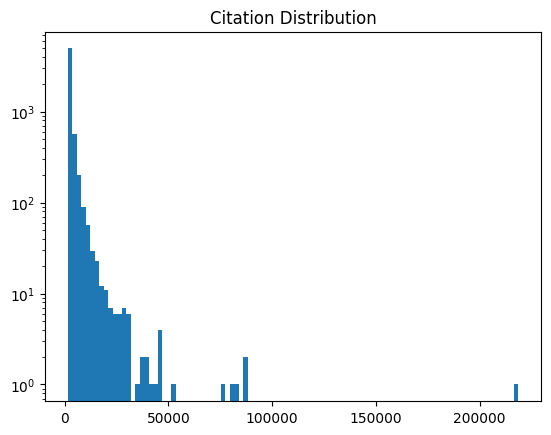

In [47]:
plt.figure()
plt.hist(df["citation_count"], bins=100, log=True)
plt.title("Citation Distribution")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

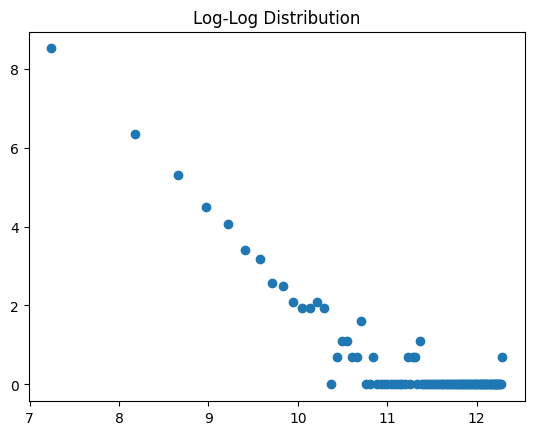

In [48]:
values = df["citation_count"] + 1
counts, bins = np.histogram(values, bins=100)

plt.figure()
plt.scatter(np.log(bins[:-1]+1), np.log(counts+1))
plt.title("Log-Log Distribution")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

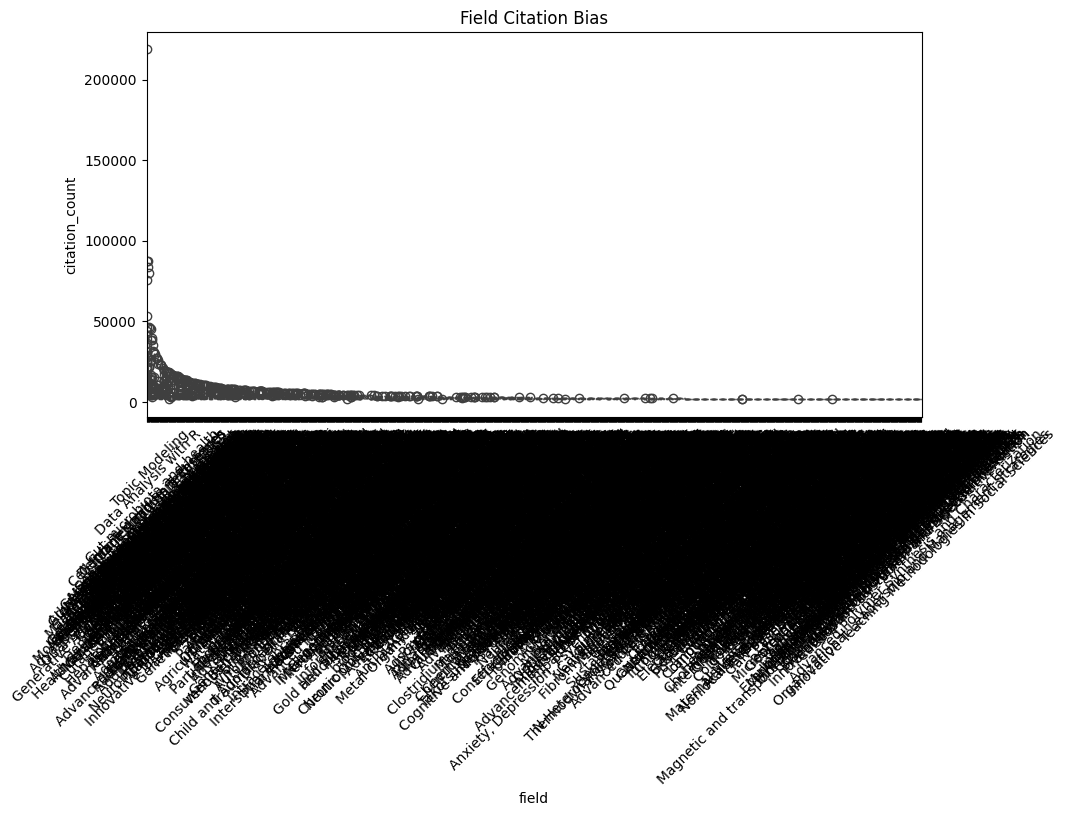

In [49]:
plt.figure(figsize=(10,5))
sns.boxplot(x="field", y="citation_count", data=df)
plt.xticks(rotation=45)
plt.title("Field Citation Bias")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

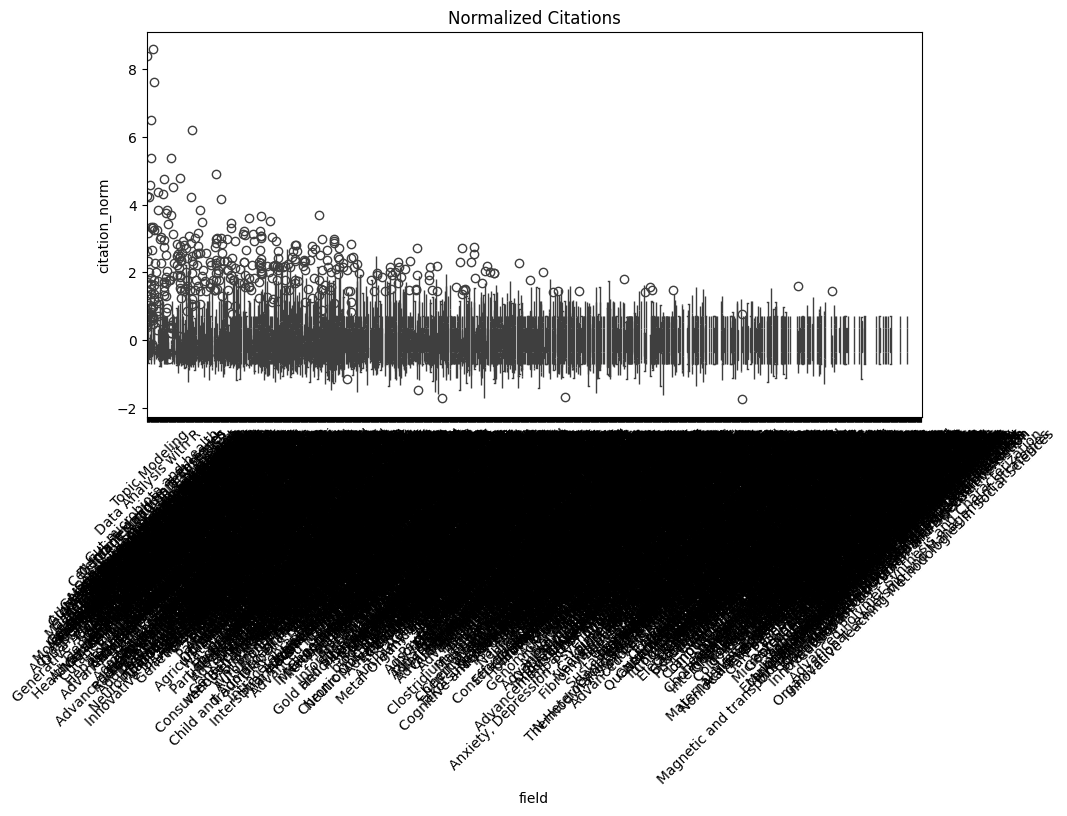

In [50]:
plt.figure(figsize=(10,5))
sns.boxplot(x="field", y="citation_norm", data=df)
plt.xticks(rotation=45)
plt.title("Normalized Citations")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

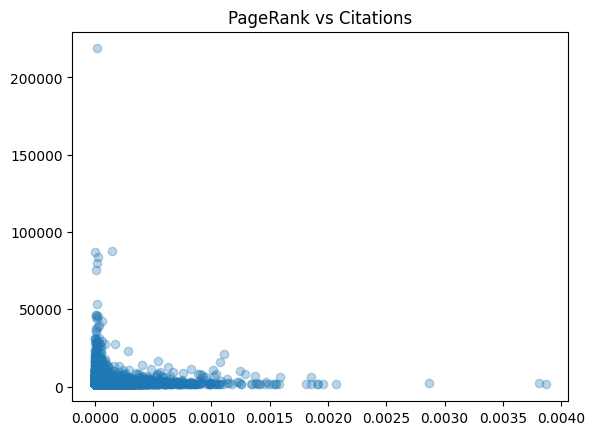

In [51]:
plt.figure()
plt.scatter(df["pagerank"], df["citation_count"], alpha=0.3)
plt.title("PageRank vs Citations")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

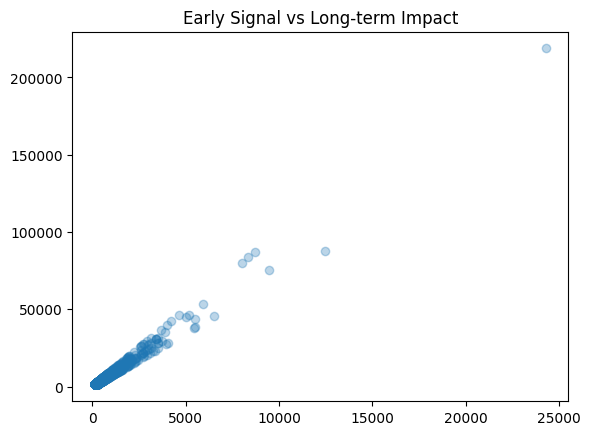

In [52]:
plt.figure()
plt.scatter(df["early_signal"], df["citation_count"], alpha=0.3)
plt.title("Early Signal vs Long-term Impact")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

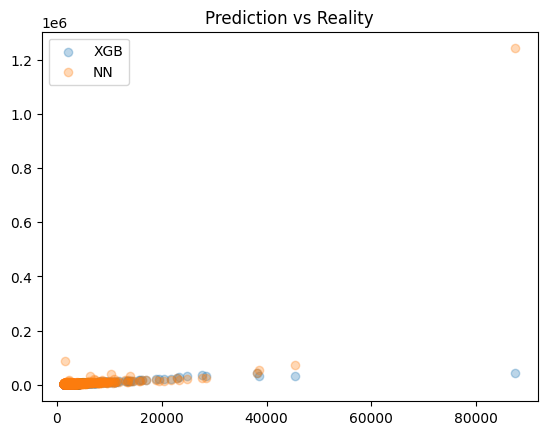

In [53]:
plt.figure()
plt.scatter(y_test_real, y_pred_xgb_real, alpha=0.3, label="XGB")
plt.scatter(y_test_real, y_pred_nn_real, alpha=0.3, label="NN")
plt.legend()
plt.title("Prediction vs Reality")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

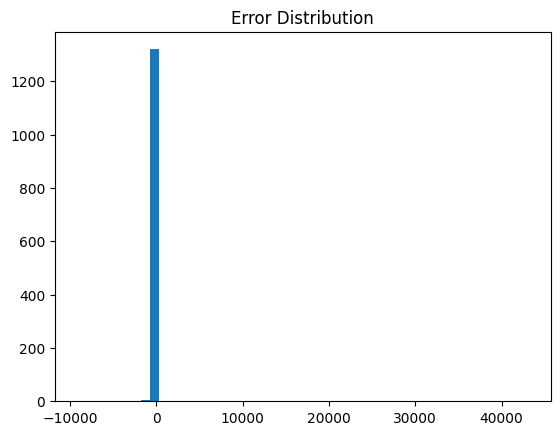

In [54]:
errors = y_test_real - y_pred_xgb_real

plt.figure()
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()
plt.savefig("plots/citation_distribution.png", dpi=300, bbox_inches='tight')
plt.close()

In [55]:
fit = powerlaw.Fit(df["citation_count"] + 1)

print("Alpha:", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 2620/2620 [00:00<00:00, 4758.78it/s]

Alpha: 2.820892815845885
xmin: 1395.0



c:\Users\Gaming\Desktop\ADS_Citation\venv\Lib\site-packages\powerlaw\distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
